In [36]:
# ! pip3 install torch

In [37]:
# ! pip install torchaudio

In [38]:
! pip install soundfile

In [69]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader
from core import *
from util import mean_and_ci
from config import NUM_CLASSES
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from matplotlib.ticker import MultipleLocator
from itertools import combinations
from scipy.stats import spearmanr, t as t_dist
from sklearn.manifold import MDS
from scipy.spatial import procrustes
import warnings
import math
from scipy.stats import spearmanr, rankdata, t as t_dist
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer

In [ ]:
# Load the data
dataset = SantoroDataset()
dataloader = DataLoader(dataset, batch_size=16, shuffle=False) # Keep shuffle=False to align with brain data
print(f"Loaded {len(dataset)} Santoro sounds.")

# Fix 1: Remove parentheses from brain_responses
brain_data = dataset.brain_responses
print(f"Brain data shape: {brain_data.shape}")

# Load YAMNet activations
yamnet_activations = load_yamnet_activations()
print(f"Loaded YAMNet activations for layers: {list(yamnet_activations.keys())}")

# Dictionaries to store lists of extracted activations for all runs
all_trained_activations = {"waveform": [], "uninspired": [], "inspired": []}
all_untrained_activations = {"waveform": [], "uninspired": [], "inspired": []}

# Path to the directory containing the model files
models_dir = Path("models") 

# Iterate through each model type independently and extract untrained weights
for model_name in ["waveform", "uninspired", "inspired"]:
    
    # Get all "best" trained runs for this specific model
    trained_files = list(models_dir.glob(f"{model_name}_run*_best.pt"))
    print(f"\nProcessing {model_name}: Found {len(trained_files)} trained runs.")
    
    # Process Trained Runs
    for pt_file in trained_files:
        trained_model = MODEL_CLASSES[model_name](num_classes=NUM_CLASSES)
        trained_model.load_state_dict(torch.load(pt_file, map_location=torch.device('cpu'), weights_only=True))

        trained_activations = extract_activations(dataloader, trained_model)
        all_trained_activations[model_name].append(trained_activations)

        # Process Untrained Model
        untrained_model = MODEL_CLASSES[model_name](num_classes=NUM_CLASSES)
        untrained_activations = extract_activations(dataloader, untrained_model)
        all_untrained_activations[model_name].append(untrained_activations)

print("\nFinished extracting all activations. Ready to compute RDMs!")

Loaded 288 Santoro sounds.
Brain data shape: torch.Size([288, 5521])
Loaded YAMNet activations for layers: ['layer01relu', 'layer02relu', 'layer03relu', 'layer04relu', 'layer05relu', 'layer06relu', 'layer07relu', 'layer08relu', 'layer09relu', 'layer10relu', 'layer11relu', 'layer12relu', 'layer13relu', 'layer14relu', 'embedding']

Processing waveform: Found 5 trained runs.

Processing uninspired: Found 5 trained runs.

Processing inspired: Found 5 trained runs.


In [ ]:
# ----- Calculate the RDMs for each model type and each run -----

# -- Functions to compute RDMs --
# Function to compute RDM using Euclidean distance
def compute_rdm_euclidean(patterns: np.ndarray) -> np.ndarray:
    """Computes the Euclidean-distance RDM for a set of representational patterns using a fast, vectorized approach."""
    # Convert to numpy if it's a PyTorch tensor
    if isinstance(patterns, torch.Tensor):
        patterns = patterns.numpy()
        
    # Flatten spatial/feature dimensions so the shape becomes (n_samples, n_features)
    n_samples = patterns.shape[0]
    patterns_flattened = patterns.reshape(n_samples, -1)
    
    # Vectorized Euclidean distance calculation using scipy. 
    # In the practical we used for-loops to calculate the RDM, but using scipy's pdist and squareform is much faster and more efficient.
    # Since we have to compute the RDM for many layers and runs, this is a very significant speedup for this assignment.
    distances = pdist(patterns_flattened, metric='euclidean')
    rdm = squareform(distances)
    
    return rdm

# Function to compute RDM using 1-Pearson correlation
def compute_rdm_1correlation(patterns: np.ndarray) -> np.ndarray:
    """Computes the 1-correlation RDM using a fast, vectorized approach."""
    # Convert to numpy if it's a PyTorch tensor
    if isinstance(patterns, torch.Tensor):
        patterns = patterns.numpy()
        
    # Flatten spatial/feature dimensions so the shape becomes (n_samples, n_features)
    n_samples = patterns.shape[0]
    patterns_flattened = patterns.reshape(n_samples, -1)
    
    # Vectorized 1-Pearson correlation across all 288 sounds simultaneously
    rdm = 1 - np.corrcoef(patterns_flattened)
    rdm = np.nan_to_num(rdm, nan=1.0) # safety measure to prevent numerical issues with NaN if a row would end up being filled with constants (zeros)
    np.fill_diagonal(rdm, 0) # Ensure the diagonal is exactly 0
    
    return rdm


In [ ]:
# Compute RDM for brain_data
print("\nComputing Brain RDM...")
brain_rdm_euclidean = compute_rdm_euclidean(brain_data) # Required for metric experiment baseline
brain_rdm_1correlation = compute_rdm_1correlation(brain_data)

# Compute RDMs for untrained models
print("Computing Untrained Models RDMs...")
untrained_rdms_1correlation = {"waveform": [], "uninspired": [], "inspired": []}

for model_name in ["waveform", "uninspired", "inspired"]:
    for run_acts in all_untrained_activations[model_name]:
        run_rdms = {}
        for layer_name, acts in run_acts.items():
            run_rdms[layer_name] = compute_rdm_1correlation(acts)
        untrained_rdms_1correlation[model_name].append(run_rdms)

# Compute RDMs for trained models
print("Computing Trained Models RDMs...")
trained_rdms_1correlation = {"waveform": [], "uninspired": [], "inspired": []}

for model_name in ["waveform", "uninspired", "inspired"]:
    for run_acts in all_trained_activations[model_name]:
        run_rdms = {}
        for layer_name, acts in run_acts.items():
            run_rdms[layer_name] = compute_rdm_1correlation(acts)
        trained_rdms_1correlation[model_name].append(run_rdms)

# Compute RDMs for YAMNet activations
print("Computing YAMNet RDMs...")
yamnet_rdms_euclidean = {} # Required for metric experiment baseline
yamnet_rdms_1correlation = {}

for layer_name, acts in yamnet_activations.items():
    yamnet_rdms_euclidean[layer_name] = compute_rdm_euclidean(acts) # ADDED: Required for metric experiment baseline
    yamnet_rdms_1correlation[layer_name] = compute_rdm_1correlation(acts)

print("All RDMs computed successfully!")

In [ ]:
# ---------------------------------------------------------
# METRIC EXPERIMENTATION: YAMNET BASELINE
# ---------------------------------------------------------
print("\nRunning Metric Selection Experiment on YAMNet...")

def upper_triangle(rdm: np.ndarray) -> np.ndarray:
    """Extract the off-diagonal upper-triangular entries of an RDM as a 1D vector."""
    return rdm[np.triu_indices(rdm.shape[0], k=1)]

def compare_rdms_pcc(rdm_a: np.ndarray, rdm_b: np.ndarray) -> float:
    """Compare two RDMs via Pearson correlation of their upper-triangular entries."""
    rdm_a = upper_triangle(rdm_a)
    rdm_b = upper_triangle(rdm_b)
    return np.corrcoef(rdm_a, rdm_b)[0, 1]

def compare_rdms_spearman(rdm_a: np.ndarray, rdm_b: np.ndarray) -> float:
    """Compare two RDMs via Spearman correlation of their upper-triangular entries."""
    rdm_a = upper_triangle(rdm_a)
    rdm_b = upper_triangle(rdm_b)
    return spearmanr(rdm_a, rdm_b).correlation

# Matrix to store the peak alignment score for each combination
results_matrix = np.zeros((2, 2))
scoring_functions = [compare_rdms_pcc, compare_rdms_spearman]

# Euclidean RDM combinations
for j, score_func in enumerate(scoring_functions):
    layer_scores = []
    for layer_name, y_rdm in yamnet_rdms_euclidean.items():
        alignment = score_func(y_rdm, brain_rdm_euclidean) # CHANGED: Uses score_func directly
        layer_scores.append(alignment)
    # Store the peak score achieved by YAMNet for this combination
    results_matrix[0, j] = max(layer_scores)

# 2. 1-Correlation RDM combinations
for j, score_func in enumerate(scoring_functions):
    layer_scores = []
    for layer_name, y_rdm in yamnet_rdms_1correlation.items():
        alignment = score_func(y_rdm, brain_rdm_1correlation) # CHANGED: Uses score_func directly
        layer_scores.append(alignment)
    # Store the peak score achieved by YAMNet for this combination
    results_matrix[1, j] = max(layer_scores)

# Format and print the results as a clean table for the report
results_df = pd.DataFrame(
    results_matrix, 
    index=['Euclidean RDM', '1-Correlation RDM'], 
    columns=['Pearson Scoring', 'Spearman Scoring']
)

print("\n--- Peak YAMNet Alignment Across Metric Combinations ---")
print(results_df.round(4))
print("--------------------------------------------------------\n")

The table above shows the peak YAMNet–STG alignment for all four combinations of dissimilarity measure and RDM comparison. 
Spearman scoring gave higher alignment than Pearson for both dissimilarity measures. 
This is consistent with a monotonic but nonlinear relationship between model and brain dissimilarities, so we used Spearman throughout. 
Euclidean RDMs gave higher alignment than 1 − correlation RDMs. However, Euclidean distance is sensitive to each response magnitude, 
so this advantage might partically reflects sound intensity rather than representational benefit of the model. 

All subsequent analyses therefore use 1 − correlation RDMs, which compare the pattern of responses, and compare these RDMs using Spearman's rank correlation. Because the same metric is applied to all models, this choice does not bias the comparisons between them.

In [ ]:
# ---------------------------------------------------------
# FINAL ANALYSIS: SCORES & PLOTS
# ---------------------------------------------------------
print("Scoring Custom Models & Generating Analysis Plots...")

models = ["waveform", "uninspired", "inspired"]
trained_layer_scores = {m: {} for m in models}
untrained_layer_scores = {m: {} for m in models}

# Score layers across all runs using Spearman
for model_name in models:
    layer_names = list(trained_rdms_1correlation[model_name][0].keys())
    
    for layer in layer_names:
        # Trained scores
        t_scores = [compare_rdms_spearman(run[layer], brain_rdm_1correlation) for run in trained_rdms_1correlation[model_name]]
        trained_layer_scores[model_name][layer] = np.array(t_scores)
        
        # Untrained scores
        u_scores = [compare_rdms_spearman(run[layer], brain_rdm_1correlation) for run in untrained_rdms_1correlation[model_name]]
        untrained_layer_scores[model_name][layer] = np.array(u_scores)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = {"waveform": "tab:blue", "uninspired": "tab:orange", "inspired": "tab:green"}

for ax, model_name in zip(axes, models):
    layer_names = list(trained_layer_scores[model_name].keys())
    x_positions = np.arange(len(layer_names))
    
    # Calculate Mean and CI
    t_means, t_cis = zip(*[mean_and_ci(trained_layer_scores[model_name][layer]) for layer in layer_names])
    u_means, u_cis = zip(*[mean_and_ci(untrained_layer_scores[model_name][layer]) for layer in layer_names])
    
    t_means, t_cis = np.array(t_means), np.array(t_cis)
    u_means, u_cis = np.array(u_means), np.array(u_cis)
    
    # Plot Untrained
    ax.plot(x_positions, u_means, color=colors[model_name], linestyle='--', label=f'{model_name} (Untrained)')
    ax.fill_between(x_positions, u_means - u_cis, u_means + u_cis, color=colors[model_name], alpha=0.1)

    # Plot Trained
    ax.plot(x_positions, t_means, color=colors[model_name], linestyle='-', label=f'{model_name} (Trained)')
    ax.fill_between(x_positions, t_means - t_cis, t_means + t_cis, color=colors[model_name], alpha=0.3)
    
    # Formatting
    ax.set_xticks(x_positions)
    ax.set_xticklabels(layer_names, rotation=45, ha="right")
    ax.set_title(f"{model_name.capitalize()} Model Alignment")
    ax.yaxis.set_major_locator(MultipleLocator(0.02))
    ax.set_xlabel("Network Depth (Layers)")
    ax.tick_params(axis="y", labelleft=True)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Spearman Correlation (Alignment to STG)")
plt.tight_layout()
plt.show()

In [ ]:
# add statistical functions to report difference in means and CI's
# make no assumptions on variances >>> Welch
def welch_diff_ci(a: np.ndarray, b: np.ndarray, confidence: float = 0.95) -> tuple[float, float]:
    """Difference of means with a Welch confidence interval.

    Args:
        a: Scores of the first group, e.g. trained runs.
        b: Scores of the second group, e.g. untrained runs.
        confidence: Confidence level of the interval.

    Returns:
        The difference mean(a) - mean(b) and the half-width of its confidence interval.
    """
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    var_a, var_b = a.var(ddof=1) / len(a), b.var(ddof=1) / len(b)
    se = np.sqrt(var_a + var_b)
    # Welch-Satterthwaite degrees of freedom, since the two groups can have different variances
    df = (var_a + var_b) ** 2 / (var_a**2 / (len(a) - 1) + var_b**2 / (len(b) - 1))
    return a.mean() - b.mean(), t_dist.ppf(0.5 + confidence / 2, df) * se


def hedges_g(a: np.ndarray, b: np.ndarray) -> float:
    """Standardized mean difference with small-sample correction.

    Args:
        a: Scores of the first group.
        b: Scores of the second group.

    Returns:
        Hedges' g for mean(a) - mean(b).
    """
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    n_a, n_b = len(a), len(b)
    pooled_sd = np.sqrt(((n_a - 1) * a.var(ddof=1) + (n_b - 1) * b.var(ddof=1)) / (n_a + n_b - 2))
    correction = 1 - 3 / (4 * (n_a + n_b) - 9)
    return (a.mean() - b.mean()) / pooled_sd * correction


def seed_consistency(run_rdms: list[dict], layer: str) -> float:
    """Mean Spearman correlation between the RDMs of all pairs of runs for one layer.

    Args:
        run_rdms: One dict {layer_name: rdm} per run.
        layer: The layer to evaluate.

    Returns:
        The average pairwise RDM similarity across runs.
    """
    pairs = combinations(range(len(run_rdms)), 2)
    return float(np.mean([compare_rdms_spearman(run_rdms[i][layer], run_rdms[j][layer]) for i, j in pairs]))

In [ ]:
# CI reporting helper functions (to make it formatted like in R)
def format_interval(mean: float, low: float, high: float, decimals: int = 2) -> str:
    """Formats a point estimate with its confidence interval as 'mean [low, high]'.

    Args:
        mean: Point estimate.
        low: Lower bound of the interval.
        high: Upper bound of the interval.
        decimals: Number of decimals to show.

    Returns:
        The formatted string, or only the mean if the interval is missing.
    """
    if np.isnan(low) or np.isnan(high):
        return f"{mean:.{decimals}f}"
    return f"{mean:.{decimals}f} [{low:.{decimals}f}, {high:.{decimals}f}]"


def interval_column(df: pd.DataFrame, mean_col: str, low_col: str, high_col: str, decimals: int = 2) -> pd.Series:
    """Builds a column of formatted intervals from three numeric columns.

    Args:
        df: Table containing the three columns.
        mean_col: Name of the point-estimate column.
        low_col: Name of the lower-bound column.
        high_col: Name of the upper-bound column.
        decimals: Number of decimals to show.

    Returns:
        A string column with one formatted interval per row.
    """
    values = df[[mean_col, low_col, high_col]].to_numpy(dtype=float)
    return pd.Series([format_interval(m, lo, hi, decimals) for m, lo, hi in values], index=df.index)

In [ ]:
rows = []
for model_name in models:
    for depth, layer in enumerate(trained_layer_scores[model_name]):
        t_scores = trained_layer_scores[model_name][layer]
        u_scores = untrained_layer_scores[model_name][layer]
        t_mean, t_ci = mean_and_ci(t_scores)
        u_mean, u_ci = mean_and_ci(u_scores)
        delta, delta_ci = welch_diff_ci(t_scores, u_scores)
        rows.append({
            "model": model_name,
            "depth": depth,
           "layer": layer,
            "n_runs": len(t_scores),
            "rho_trained": t_mean,
            "trained_ci_low": t_mean - t_ci,
            "trained_ci_high": t_mean + t_ci,
            "rho_untrained": u_mean,
            "untrained_ci_low": u_mean - u_ci,
            "untrained_ci_high": u_mean + u_ci,
            "delta": delta,
            "delta_ci_low": delta - delta_ci,
            "delta_ci_high": delta + delta_ci,
            "hedges_g": hedges_g(t_scores, u_scores),
            "consistency_trained": seed_consistency(trained_rdms_1correlation[model_name], layer),
            "consistency_untrained": seed_consistency(untrained_rdms_1correlation[model_name], layer),
        })
summary_df = pd.DataFrame(rows)

peak_rows = []
for model_name, group in summary_df.groupby("model", sort=False):
    for condition in ["trained", "untrained"]:
        best = group.loc[group[f"rho_{condition}"].idxmax()]
        peak_rows.append({
            "model": model_name,
            "condition": condition,
            "best_layer": best["layer"],
            "rho": best[f"rho_{condition}"],
            "ci_low": best[f"{condition}_ci_low"],
            "ci_high": best[f"{condition}_ci_high"],
        })
peak_rows.append({
    "model": "yamnet",
    "condition": "pretrained",
    "best_layer": list(yamnet_rdms_1correlation)[int(np.argmax([
        compare_rdms_spearman(rdm, brain_rdm_1correlation) for rdm in yamnet_rdms_1correlation.values()
    ]))],
    "rho": results_matrix[1, 1],
    "ci_low": np.nan,
    "ci_high": np.nan,
})
peak_df = pd.DataFrame(peak_rows)

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
summary_df.to_csv(results_dir / "training_effect_per_layer.csv", index=False)
peak_df.to_csv(results_dir / "peak_alignment.csv", index=False)

summary_display = pd.DataFrame({
    "model": summary_df["model"],
    "depth": summary_df["depth"],
    "trained": interval_column(summary_df, "rho_trained", "trained_ci_low", "trained_ci_high"),
    "untrained": interval_column(summary_df, "rho_untrained", "untrained_ci_low", "untrained_ci_high"),
    "delta (trained - untrained)": interval_column(summary_df, "delta", "delta_ci_low", "delta_ci_high"),
    "hedges_g": summary_df["hedges_g"].map("{: .2f}".format),
    "seed_cons_trained": summary_df["consistency_trained"].map("{: .2f}".format),
    "seed_cons_untrained": summary_df["consistency_untrained"].map("{: .2f}".format),
})

peak_display = pd.DataFrame({
    "model": peak_df["model"],
    "condition": peak_df["condition"],
    "best_layer": peak_df["best_layer"],
    "rho": interval_column(peak_df, "rho", "ci_low", "ci_high"),
})

interval_space = interval_space = {"trained": 23, "untrained": 23, "delta (trained - untrained)": 23, "rho": 23}
layer_width = peak_display["best_layer"].str.len().max()

print("\nTraining effect per layer: Spearman rho, 1-correlation RDM, mean [95% CI]")
for model_name, block in summary_display.groupby("model", sort=False):
    print(f"\n{model_name}")
    print(block.drop(columns="model").to_string(
        index=False,
        col_space={k: v for k, v in interval_space.items() if k in block},
    ))

print("\nPeak alignment per model: Spearman rho, mean [95% CI]")
print(peak_display.to_string(
    index=False,
    col_space={"rho": interval_space["rho"]},
    formatters={"best_layer": lambda s: f"{s:<{layer_width}}"},
))

The table above summarizes the effect of training per layer. 
All alignment values are small, compared with 0.10 for the much larger YAMNet. 
The effect of training depends on depth. In early and middle layers, training increased alignment: in the uninspired model by 0.02–0.04 (layers 0–2), and in the inspired model by 0.06–0.08 (layers 1–2, where alignment turned from negative to positive). 

In the deep layers the effect reversed: untrained networks aligned better than trained ones in the last three layers of the uninspired model, while the inspired model showed no clear difference in its last two layers (CIs including zero). 
The peak alignment of untrained networks was equal to or higher than that of trained networks (uninspired 0.06 vs 0.03, inspired 0.07 vs 0.05). The waveform model was negative in all layers. Training reduced its anti-alignment in the middle layers, but did not bring it above zero.
The large Hedges' g values (up to 4.6) reflect the small variability across seeds rather than large effects. Absolute differences stayed below 0.08 in rho units.

Seed consistency shows how training shapes the representations themselves. For the uninspired and inspired models, different runs produced very similar RDMs, both untrained (0.65–0.87) and trained (0.76–0.96). Training made the runs converge further, so the architecture largely determines the representational geometry, and training refines it consistently. The waveform model showed the opposite: untrained runs were moderately consistent (0.21–0.61), but after training, runs agreed almost not at all beyond the first layer (0.04–0.10). Each trained waveform network thus learned its own geometry, so its alignment scores describe a family of different representations rather than one stable solution.

#### The Effect of Training on Brain Alignment
To make a conclusion on the effect of training on brain alignment, we will run a permutation test

In [ ]:
def standardized_ranks(rdm: np.ndarray) -> np.ndarray:
    """Ranks the upper-triangular entries of an RDM and z-scores the ranks.

    Args:
        rdm: Square dissimilarity matrix.

    Returns:
        The z-scored ranks as a 1D vector. Their mean product with another such vector is Spearman's rho.
    """
    ranks = rankdata(upper_triangle(rdm))
    return (ranks - ranks.mean()) / ranks.std()


def brain_permutation_test(
    brain_rdm: np.ndarray,
    model_rdms: dict[tuple, list[np.ndarray]],
    n_permutations: int = 1000,
    seed: int = 0,
) -> tuple[list[tuple], np.ndarray, np.ndarray]:
    """Tests mean model-brain alignment against a null built by permuting the brain data.

    Each permutation reorders the sounds of the brain RDM (rows and columns together), which is
    equivalent to permuting the rows of the brain data. The same permutations are used for every
    model RDM, so the null distributions are directly comparable.

    Args:
        brain_rdm: The (n_sounds, n_sounds) brain RDM.
        model_rdms: Maps a key, e.g. (model, condition, layer), to the RDMs of all runs.
        n_permutations: Number of permutations.
        seed: Random seed.

    Returns:
        The keys, the observed mean Spearman rho per key, and the null matrix of shape
        (n_permutations, n_keys).
    """
    keys = list(model_rdms)
    vectors, owner = [], []
    for key_idx, key in enumerate(keys):
        for rdm in model_rdms[key]:
            vectors.append(standardized_ranks(rdm))
            owner.append(key_idx)
    model_matrix = np.vstack(vectors)
    owner = np.array(owner)

    # averaging matrix: turns per-run scores into the mean score per key
    averaging = np.zeros((len(keys), len(owner)))
    averaging[owner, np.arange(len(owner))] = 1
    averaging /= averaging.sum(axis=1, keepdims=True)

    n_sounds = brain_rdm.shape[0]
    iu = np.triu_indices(n_sounds, k=1)
    n_pairs = len(iu[0])

    # z-scored brain ranks placed back into a symmetric matrix, so a permutation is just re-indexing
    brain_z = np.zeros((n_sounds, n_sounds))
    brain_z[iu] = standardized_ranks(brain_rdm)
    brain_z = brain_z + brain_z.T

    observed = averaging @ (model_matrix @ brain_z[iu] / n_pairs)

    rng = np.random.default_rng(seed)
    null = np.empty((n_permutations, len(keys)))
    for k in range(n_permutations):
        perm = rng.permutation(n_sounds)
        permuted = brain_z[np.ix_(perm, perm)][iu]
        null[k] = averaging @ (model_matrix @ permuted / n_pairs)

    return keys, observed, null


def label_permutation_test(a: np.ndarray, b: np.ndarray, max_permutations: int = 10000, seed: int = 0) -> float:
    """Two-sided permutation test for a difference in means between two groups of runs.

    Enumerates all splits exactly when there are at most max_permutations of them,
    otherwise samples random splits.

    Args:
        a: Scores of the first group, e.g. trained runs.
        b: Scores of the second group, e.g. untrained runs.
        max_permutations: Upper limit on the number of splits.
        seed: Random seed for the sampled case.

    Returns:
        The two-sided p-value.
    """
    pooled = np.concatenate([a, b])
    n_a, n_total = len(a), len(pooled)
    observed = abs(np.mean(a) - np.mean(b))

    if math.comb(n_total, n_a) <= max_permutations:
        splits = [np.array(c) for c in combinations(range(n_total), n_a)]
        diffs = []
        for idx in splits:
            mask = np.zeros(n_total, dtype=bool)
            mask[idx] = True
            diffs.append(abs(pooled[mask].mean() - pooled[~mask].mean()))
        diffs = np.array(diffs)
        return float(np.mean(diffs >= observed - 1e-12))

    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(max_permutations):
        shuffled = rng.permutation(pooled)
        count += abs(shuffled[:n_a].mean() - shuffled[n_a:].mean()) >= observed - 1e-12
    return (1 + count) / (1 + max_permutations)

In [ ]:
model_rdms = {}
for model_name in models:
    for layer in trained_layer_scores[model_name]:
        model_rdms[(model_name, "trained", layer)] = [run[layer] for run in trained_rdms_1correlation[model_name]]
        model_rdms[(model_name, "untrained", layer)] = [run[layer] for run in untrained_rdms_1correlation[model_name]]

n_permutations = 1000
keys, observed, null = brain_permutation_test(brain_rdm_1correlation, model_rdms, n_permutations=n_permutations)

p_chance = (1 + (null >= observed).sum(axis=0)) / (1 + n_permutations)

# max-statistic correction across the layers of each model and condition
p_chance_fwe = np.empty(len(keys))
for group in {(m, c) for m, c, _ in keys}:
    idx = [i for i, (m, c, _) in enumerate(keys) if (m, c) == group]
    null_max = null[:, idx].max(axis=1)
    p_chance_fwe[idx] = (1 + (null_max[:, None] >= observed[idx]).sum(axis=0)) / (1 + n_permutations)

p_lookup = {key: (p, p_fwe) for key, p, p_fwe in zip(keys, p_chance, p_chance_fwe)}
summary_df["p_trained"] = [p_lookup[(m, "trained", l)][1] for m, l in zip(summary_df["model"], summary_df["layer"])]
summary_df["p_untrained"] = [p_lookup[(m, "untrained", l)][1] for m, l in zip(summary_df["model"], summary_df["layer"])]
summary_df["p_delta"] = [
    label_permutation_test(trained_layer_scores[m][l], untrained_layer_scores[m][l])
    for m, l in zip(summary_df["model"], summary_df["layer"])
]

In [ ]:
# helpers to report permutations test results + bonferroni holm correction for multiple tests
# 17 layers and three models need adjustment for multiple testing
def holm_correction(p_values: np.ndarray) -> np.ndarray:
    """Holm-Bonferroni adjustment of a set of p-values.

    Args:
        p_values: Uncorrected p-values of one family of tests.

    Returns:
        The adjusted p-values, in the original order.
    """
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    running_max = 0.0
    for rank, idx in enumerate(order):
        running_max = max(running_max, (len(p) - rank) * p[idx])
        adjusted[idx] = min(running_max, 1.0)
    return adjusted


def format_p(p: float) -> str:
    """Formats a p-value with R-style significance codes.

    Args:
        p: The p-value.

    Returns:
        The p-value with three decimals followed by its significance code.
    """
    if p < 0.001:
        code = "***"
    elif p < 0.01:
        code = "**"
    elif p < 0.05:
        code = "*"
    elif p < 0.1:
        code = "."
    else:
        code = ""
    return f"{p:.3f} {code:<3}"

In [ ]:
summary_df["p_delta_holm"] = summary_df.groupby("model")["p_delta"].transform(holm_correction)

perm_display = pd.DataFrame({
    "model": summary_df["model"],
    "depth": summary_df["depth"],
    "rho_trained": summary_df["rho_trained"].map("{: .3f}".format),
    "p_trained": summary_df["p_trained"].map(format_p),
    "rho_untrained": summary_df["rho_untrained"].map("{: .3f}".format),
    "p_untrained": summary_df["p_untrained"].map(format_p),
    "delta (trained - untrained)": summary_df["delta"].map("{: .3f}".format),
    "p_delta": summary_df["p_delta_holm"].map(format_p),
})

n_runs = int(summary_df["n_runs"].iloc[0])
print(f"\nPermutation tests (Spearman rho, 1-correlation RDM, {n_runs} runs per condition)")
print(f"  p_trained / p_untrained: alignment above chance, {n_permutations} permutations of the brain data,")
print("                           one-sided, max-statistic corrected across layers")
print("  p_delta: trained vs untrained, permutation of run labels, two-sided, Holm corrected across layers")

for model_name, block in perm_display.groupby("model", sort=False):
    print(f"\n{model_name}")
    print(block.drop(columns="model").to_string(index=False))

print("\n---")
print("Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1")

**Training effect.**
Although training changed alignment in several layers (uninspired, all layers; inspired, layers 1–2; waveform, layer 3; permutation of run labels, Holm corrected),
we do not consider this a meaningful improvement, for three reasons. First, no layer of any model, trained or untrained, was aligned with STG above chance after correction for multiple comparisons, 
so training shifts alignment only within the range expected by chance. Second, the differences are small in absolute terms (Delta rho  0.08) and change sign with depth: 
training increased alignment in early and middle layers but decreased it in deep layers.
Third, with five runs per condition the smallest attainable corrected p-value is 0.048 (0.040 for the five-layer inspired model). The observed p-values sit exactly at this floor, which indicates complete separation of trained and untrained runs, but gives no information on how robust this separation is. We therefore interpret these results as weak evidence at the resolution limit of the test, not as a reliable training benefit.

**Waveform model and follow-up.** The waveform model showed negative alignment in all layers. 
The waveform model showed negative alignment with STG in all layers, most strongly in the earliest layers (trained layer 0: rho = -0.068; untrained layer 1: rho = -0.080). 
The one-sided permutation test used so far only asks whether a model aligns with STG better than chance, so for these negative values it returns p ~ 1. 
It cannot tell whether the model is simply unrelated to STG or systematically anti-aligned, representing as similar the sound pairs that STG represents as different. 
We will therefore run a two-sided version of the same test, which evaluates the absolute size of the alignment, rho, against the permutation null. 

In [ ]:
p_two_sided_fwe = np.empty(len(keys))
for group in {(m, c) for m, c, _ in keys}:
    idx = [i for i, (m, c, _) in enumerate(keys) if (m, c) == group]
    null_max_abs = np.abs(null[:, idx]).max(axis=1)
    p_two_sided_fwe[idx] = (1 + (null_max_abs[:, None] >= np.abs(observed[idx])).sum(axis=0)) / (1 + n_permutations)

waveform_rows = [
    {"condition": c, "layer": l, "rho": observed[i], "p_two_sided": p_two_sided_fwe[i]}
    for i, (m, c, l) in enumerate(keys) if m == "waveform"
]
waveform_df = pd.DataFrame(waveform_rows)
waveform_df["rho"] = waveform_df["rho"].map("{: .3f}".format)
waveform_df["p_two_sided"] = waveform_df["p_two_sided"].map(format_p)

print("\nWaveform: two-sided test against chance (brain permutation, max-statistic corrected)")
for condition, block in waveform_df.groupby("condition", sort=False):
    print(f"\n{condition}")
    print(block.drop(columns="condition").to_string(index=False))

The two-sided test shows that the anti-alignment is significant only in the earliest layers: trained layer 0 (rho = -0.068, p = 0.004) and untrained layer 1 (rho = -0.080, p = 0.042). 
All other layers are negative but within the range expected by chance. So the waveform model is not systematically anti-aligned throughout. 
The effect is concentrated at the input stage, where the representation is closest to the raw audio signal. With training, the anti-alignment weakens in the deeper layers (from about -0.06 to about -0.03) but persists in the first layer.

Because the effect sits in the layers nearest the raw waveform, we suspect it reflects a low-level acoustic property rather than learned representational content. As a next step, we will build a control RDM from each sound's loudness (the absolute difference in log RMS energy between sound pairs), and compare it with both the brain RDM and the waveform layers. If STG and the waveform model relate to loudness in opposite directions, that would explain the negative alignment.

In [ ]:
log_rms = []
for i in range(len(dataset)):
    item = dataset[i]
    audio = item[0] if isinstance(item, (tuple, list)) else item
    audio = audio.numpy() if isinstance(audio, torch.Tensor) else np.asarray(audio)
    log_rms.append(np.log(np.sqrt(np.mean(audio**2)) + 1e-12))
log_rms = np.array(log_rms)
loudness_rdm = np.abs(log_rms[:, None] - log_rms[None, :])

print(f"\nLoudness RDM vs brain RDM: Spearman rho = {compare_rdms_spearman(loudness_rdm, brain_rdm_1correlation): .3f}")

loudness_rows = []
for model_name in models:
    for depth, layer in enumerate(trained_layer_scores[model_name]):
        loudness_rows.append({
            "model": model_name,
            "depth": depth,
            "trained": np.mean([compare_rdms_spearman(run[layer], loudness_rdm)
                                for run in trained_rdms_1correlation[model_name]]),
            "untrained": np.mean([compare_rdms_spearman(run[layer], loudness_rdm)
                                  for run in untrained_rdms_1correlation[model_name]]),
        })
loudness_df = pd.DataFrame(loudness_rows)

print("\nModel RDMs vs loudness RDM (mean Spearman rho over runs)")
for model_name, block in loudness_df.groupby("model", sort=False):
    print(f"\n{model_name}")
    print(block.drop(columns="model").to_string(index=False, float_format="{: .3f}".format))

The loudness control RDM correlates positively with the STG RDM (rho = 0.113). That's comparable to YAMNet's peak alignment (0.10) and higher than any of our models. 
So even after removing each pattern's overall level with 1 − correlation, STG's representational geometry still reflects how loud the sounds are. 
The waveform model shows the opposite relationship: all its layers correlate negatively with loudness, most strongly in the untrained network (up to rho = -0.67) and in the earliest layers. 
These are the same layers that were significantly anti-aligned with STG, so the waveform model's negative alignment is plausibly explained by its reversed encoding of loudness. 
Training weakens this anti-correlation (for example from -0.67 to -0.14 in layer 1), and brain alignment becomes less negative accordingly.

#### Effects of the Architectural Choices on Brain Alignment

In [ ]:
def per_run_summary(layer_scores: dict[str, np.ndarray], how: str = "peak") -> np.ndarray:
    """Reduces the per-layer scores of each run to one value per run.

    Args:
        layer_scores: Maps each layer name to an array with one score per run.
        how: "peak" for the best layer of each run, "mean" for the average over layers.

    Returns:
        One summary score per run.
    """
    scores = np.vstack(list(layer_scores.values()))
    return scores.max(axis=0) if how == "peak" else scores.mean(axis=0)

In [ ]:
conditions = {"trained": trained_layer_scores, "untrained": untrained_layer_scores}
summaries = ["peak", "mean"]

arch_rows, pair_rows = [], []
for condition, layer_scores in conditions.items():
    for how in summaries:
        values = {m: per_run_summary(layer_scores[m], how) for m in models}

        for model_name in models:
            mean, ci = mean_and_ci(values[model_name])
            arch_rows.append({
                "condition": condition, "summary": how, "model": model_name,
                "rho": mean, "ci_low": mean - ci, "ci_high": mean + ci,
            })

        family = []
        for model_a, model_b in combinations(models, 2):
            delta, delta_ci = welch_diff_ci(values[model_a], values[model_b])
            family.append({
                "condition": condition, "summary": how, "comparison": f"{model_a} - {model_b}",
                "delta": delta, "ci_low": delta - delta_ci, "ci_high": delta + delta_ci,
                "p": label_permutation_test(values[model_a], values[model_b]),
            })
        adjusted = holm_correction([row["p"] for row in family])
        for row, p_holm in zip(family, adjusted):
            row["p_holm"] = p_holm
        pair_rows.extend(family)

arch_df = pd.DataFrame(arch_rows)
pair_df = pd.DataFrame(pair_rows)
arch_df.to_csv(results_dir / "architecture_scores.csv", index=False)
pair_df.to_csv(results_dir / "architecture_comparisons.csv", index=False)

In [ ]:
arch_display = pd.DataFrame({
    "condition": arch_df["condition"],
    "summary": arch_df["summary"],
    "model": arch_df["model"],
    "rho [95% CI]": interval_column(arch_df, "rho", "ci_low", "ci_high", decimals=3),
})
pair_display = pd.DataFrame({
    "condition": pair_df["condition"],
    "summary": pair_df["summary"],
    "comparison": pair_df["comparison"],
    "delta [95% CI]": interval_column(pair_df, "delta", "ci_low", "ci_high", decimals=3),
    "p_holm": pair_df["p_holm"].map(format_p),
})

n_runs = len(next(iter(trained_layer_scores[models[0]].values())))
print(f"\nArchitecture comparison (Spearman rho, 1-correlation RDM, {n_runs} runs per model)")
print("  peak: best layer per run; mean: average over layers per run")
print("  p_holm: permutation of architecture labels across runs, two-sided, Holm corrected over 3 pairs")

for (condition, how), block in arch_display.groupby(["condition", "summary"], sort=False):
    print(f"\n{condition}, {how}")
    print(block.drop(columns=["condition", "summary"]).to_string(index=False))
    pairs = pair_display[(pair_display["condition"] == condition) & (pair_display["summary"] == how)]
    print(pairs.drop(columns=["condition", "summary"]).to_string(index=False))

print("\n---")
print("Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1")

To compare architectures, we summarized each run by its best layer (peak) and by its average over layers (mean), and tested pairwise differences by permuting architecture labels across runs (two-sided, Holm corrected over three pairs). 
**The waveform model** aligned **worst** in all settings, with negative alignment even at its best layer (rho = -0.019 trained, -0.050 untrained; all p_Holm = 0.024, the smallest attainable value). 
Untrained, the uninspired and inspired models did not differ (peak 0.061 vs 0.067, p = 0.54). 
Trained, the inspired model reached higher peak alignment than the uninspired model (0.058 vs 0.033, delta = −0.025 [−0.038, −0.011], p = 0.024). This difference arises because training reduced the peak alignment of the uninspired model more strongly (0.061 >>> 0.033) than that of the inspired model (0.067 >>> 0.058), not because training increased alignment. Averaged over layers, the difference was in the same direction but not significant (p = 0.079), indicating that the inspired advantage is confined to its best layers. Since no model was aligned above chance on its own, we interpret these results as models differ reliably from each other, but none differs reliably from zero.

#### How Well Layers at Different Depths of the Models Align with Brain Data of the STG

In [ ]:
# helper functions
def slope_over_depth(relative_depth: np.ndarray, scores: np.ndarray) -> np.ndarray:
    """Least-squares slope of alignment against relative depth.

    Args:
        relative_depth: Relative depth of each layer, shape (n_layers,).
        scores: Alignment per layer, shape (..., n_layers). Leading dimensions are kept,
            so this works for one profile, for all runs, or for all permutations at once.

    Returns:
        The slope for each profile.
    """
    x = relative_depth - relative_depth.mean()
    y = scores - scores.mean(axis=-1, keepdims=True)
    return (y @ x) / (x @ x)

In [ ]:
key_position = {key: i for i, key in enumerate(keys)}
depth_rows = []

for model_name in models:
    layer_names = list(trained_layer_scores[model_name])
    relative_depth = np.linspace(0, 1, len(layer_names))

    for condition, layer_scores in conditions.items():
        per_run = np.vstack([layer_scores[model_name][layer] for layer in layer_names]).T
        run_slopes = slope_over_depth(relative_depth, per_run)
        slope_mean, slope_ci = mean_and_ci(run_slopes)

        idx = [key_position[(model_name, condition, layer)] for layer in layer_names]
        observed_slope = slope_over_depth(relative_depth, observed[idx])
        null_slopes = slope_over_depth(relative_depth, null[:, idx])
        p_slope = (1 + (np.abs(null_slopes) >= abs(observed_slope)).sum()) / (1 + n_permutations)

        peak_depth = relative_depth[per_run.argmax(axis=1)]
        peak_mean, peak_ci = mean_and_ci(peak_depth)

        depth_rows.append({
            "model": model_name, "condition": condition,
            "slope": slope_mean, "slope_ci_low": slope_mean - slope_ci, "slope_ci_high": slope_mean + slope_ci,
            "p_slope": p_slope,
            "peak_depth": peak_mean, "peak_ci_low": peak_mean - peak_ci, "peak_ci_high": peak_mean + peak_ci,
        })

depth_df = pd.DataFrame(depth_rows)
depth_df["p_slope_holm"] = holm_correction(depth_df["p_slope"].to_numpy())
depth_df.to_csv(results_dir / "depth_trend.csv", index=False)

depth_display = pd.DataFrame({
    "model": depth_df["model"],
    "condition": depth_df["condition"],
    "slope [95% CI]": interval_column(depth_df, "slope", "slope_ci_low", "slope_ci_high", decimals=3),
    "p_slope": depth_df["p_slope_holm"].map(format_p),
    "peak depth [95% CI]": interval_column(depth_df, "peak_depth", "peak_ci_low", "peak_ci_high", decimals=2),
})

print(f"\nDepth analysis (Spearman rho, 1-correlation RDM, relative depth 0 = input, 1 = output)")
print("  slope: change in rho from first to last layer (per-run mean, 95% CI over runs)")
print(f"  p_slope: slope of mean profile vs brain permutation null ({n_permutations} permutations),")
print("           two-sided, Holm corrected over the 6 model x condition profiles")
print("  peak depth: relative depth of each run's best layer")
print()
print(depth_display.to_string(index=False))
print("\n---")
print("Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1")

In [ ]:
yamnet_scores = np.array([compare_rdms_spearman(rdm, brain_rdm_1correlation)
                          for rdm in yamnet_rdms_1correlation.values()])
yamnet_depth = np.linspace(0, 1, len(yamnet_scores))

fig, ax = plt.subplots(figsize=(9, 5))
for model_name in models:
    layer_names = list(trained_layer_scores[model_name])
    relative_depth = np.linspace(0, 1, len(layer_names))
    for condition, layer_scores in conditions.items():
        means, cis = map(np.array, zip(*[mean_and_ci(layer_scores[model_name][l]) for l in layer_names]))
        style = "-" if condition == "trained" else "--"
        ax.plot(relative_depth, means, style, marker="o", color=colors[model_name],
                label=f"{model_name} ({condition})")
        ax.fill_between(relative_depth, means - cis, means + cis, color=colors[model_name],
                        alpha=0.25 if condition == "trained" else 0.1)

ax.plot(yamnet_depth, yamnet_scores, ":", marker=".", color="black", label="yamnet (pretrained)")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Relative depth (0 = input, 1 = output)")
ax.set_ylabel(r"Spearman $\rho$ (1 − corr RDM vs STG)")
ax.set_title("Alignment with STG across network depth")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Alignment with STG increased with depth in the uninspired and inspired models. 
It went from negative values at the input to positive values in the deeper layers, with peaks in the later part of the network (mean relative peak depth 0.75–0.92). 
The depth slopes were positive and highly consistent across runs (0.08 to 0.15 per unit of relative depth, CIs excluding zero). 
Tested against the brain permutation null, however, only the untrained inspired model showed a significant trend (p = 0.036, Holm corrected). 
So the increase with depth is reproducible across seeds, but mostly not larger than chance.

Training changed the shape rather than the direction of the profile: trained models rose earlier and aligned better in early and middle layers. 
Untrained models rose more steeply and reached similar or higher values in the deepest layers (for example uninspired, slope 0.080 trained vs 0.149 untrained). 

The waveform model showed no depth trend and remained negative at all depths. The peak location of its runs varied widely (CIs spanning 0.2–0.95). 

YAMNet, as a reference, showed a noisier profile, with its highest alignment at a late intermediate layer. 
Overall, the non-waveform models align best with STG in their later layers, consistent with STG as a non-primary auditory region. 
The steep rise of the untrained models, however, coincides with increasing loudness structure in their deep layers, so part of this depth effect may reflect loudness rather than a processing hierarchy.

#### Visualize How the Layers of the Models Distinguish Categories and Compare the Results to the Brain Data

We are not t_SNE haters, but we will use non-metric Multi-Dimensional Scaling (MDS) based on 1 − correlation RDMs used in the RSA. We believe that MDS is a good fit for purpose because it operates directly on the RDM, 
so each map shows the geometry that was actually compared with STG, rather than a separate transformation of the raw activations.

Also important to note that non-metric MDS preserves only the rank order of the dissimilarities not the absolute distance, the same assumption underlying our Spearman comparison. Also, we thought it is important that, unlike t-SNE, MDS preserves all pairwise dissimilarities and not only local neighborhoods. 
Because MDS is unsupervised, the category structure visible in the maps reflects the representation itself, not the labels. We report the Kruskal stress of each solution as a measure of how well the two-dimensional map reflects the full RDM. Maps were aligned to the STG map with a Procrustes transformation (rotation, reflection and scaling only), so that corresponding sounds appear in comparable positions across panels.

In [ ]:
# analyze the distribution of labels
category_labels = np.asarray(dataset.categories)
category_counts = (
    pd.Series(category_labels, name="category")
    .value_counts()
    .rename_axis("category")
    .reset_index(name="n_sounds")
)
category_counts["percent"] = 100 * category_counts["n_sounds"] / category_counts["n_sounds"].sum()

print(f"\nCategory distribution ({len(category_labels)} sounds, {len(category_counts)} categories)")
print(category_counts.to_string(index=False, float_format="{:.1f}".format))

n = category_counts["n_sounds"]
print(f"\nmin {n.min()}, median {n.median():.0f}, max {n.max()} sounds per category")
print(f"imbalance ratio (largest / smallest): {n.max() / n.min():.1f}")
too_small = category_counts.loc[n < 5, "category"].tolist()
print(f"categories with fewer than 5 sounds (too small for 5-fold CV): {too_small if too_small else 'none'}")

In [ ]:
# create groups for visualization purposes
fine_to_group = {
    "ocean": "water", "river": "water", "water": "water", "waves": "water", "waterfall": "water",
    "drum": "drums", "percussion": "drums",
    "piano": "piano/keys", "keys": "piano/keys",
    "flute": "woodwinds", "clarinet": "woodwinds",
    "trumpet": "brass", "horn": "brass",
    "organ": "organ/synth/reeds", "synthesizer": "organ/synth/reeds", "harmonica": "organ/synth/reeds",
    "accordion": "organ/synth/reeds", "bagpipe": "organ/synth/reeds",
    "violin": "strings", "harp": "strings", "sitar": "strings", "bass": "strings", "ensamble": "strings",
    "bell": "bells/clock", "bells": "bells/clock", "chimes": "bells/clock", "clock": "bells/clock",
    "sawing": "tools", "cutting": "tools", "hammer": "tools",
    "door": "door/handling", "zipper": "door/handling", "paper": "door/handling",
    "dishes": "objects", "glass": "objects", "bottle": "objects", "metal": "objects", "wood": "objects",
    "dice": "objects",
    "toilet": "household", "toothbrush": "household", "brush": "household", "hairdryer": "household",
    "typewriter": "household", "elastic": "household",
    "engine": "vehicles", "motor": "vehicles", "car": "vehicles",
    "phone": "alarms/bangs", "siren": "alarms/bangs", "whistle": "alarms/bangs", "gun": "alarms/bangs",
    "firework": "alarms/bangs",
    "pig": "farm animals", "sheep": "farm animals", "goat": "farm animals",
    "cat": "other mammals", "cow": "other mammals", "horse": "other mammals", "wolf": "other mammals",
    "duck": "duck/insect", "insect": "duck/insect",
}

grouped_labels = np.array([fine_to_group.get(c, c) for c in category_labels])

small = category_counts.loc[category_counts["n_sounds"] < 6, "category"]
print("small categories without a group:", [c for c in small if c not in fine_to_group] or "none")

In [82]:
# downsample man and woman for viz purposes
n_keep = 16
rng = np.random.default_rng(0)

keep_idx = []
for label in np.unique(grouped_labels):
    idx = np.flatnonzero(grouped_labels == label)
    if label in ("man", "woman") and len(idx) > n_keep:
        idx = rng.choice(idx, n_keep, replace=False)
    keep_idx.extend(idx)
keep_idx = np.sort(np.array(keep_idx))
subset_labels = grouped_labels[keep_idx]

subset_counts = pd.Series(subset_labels).value_counts()
print(f"\n{len(keep_idx)} sounds, {len(subset_counts)} classes, "
      f"min {subset_counts.min()}, max {subset_counts.max()} per class")
print(subset_counts.to_string())



240 sounds, 28 classes, min 5, max 16 per class
baby                 16
man                  16
woman                16
rain                 15
thunder              13
wind                 12
water                 9
organ/synth/reeds     9
guitar                8
bird                  8
piano/keys            8
dog                   8
drums                 7
farm animals          7
household             7
objects               7
alarms/bangs          7
monkey                7
other mammals         7
brass                 7
woodwinds             7
chicken               6
strings               6
door/handling         6
tools                 6
duck/insect           5
vehicles              5
bells/clock           5


In [76]:
# group broad categories to make sure they have the same shade
class_domains = {
    "voices": ("Blues", ["man", "woman", "baby"]),
    "animals": ("Oranges", ["dog", "monkey", "bird", "chicken"]),
    "natural forces": ("Greens", ["rain", "thunder", "wind", "water"]),
    "music": ("Purples", ["guitar", "piano/keys", "drums"]),
    "mechanical": ("Reds", ["tools", "vehicles"]),
}
class_colors = build_class_colors(class_domains)

In [74]:
# helper functions
def build_class_colors(domains: dict[str, tuple[str, list[str]]]) -> dict[str, tuple]:
    """Assigns each class a shade from its domain's color family.

    Args:
        domains: Maps a domain name to (matplotlib sequential colormap, classes in that domain).

    Returns:
        Maps each class to an RGBA color. Classes of one domain share a hue and differ in shade.
    """
    class_colors = {}
    for cmap_name, classes in domains.values():
        cmap = plt.get_cmap(cmap_name)
        # skip the palest part of the colormap, which would be hard to tell apart from the grey background points
        shades = np.linspace(0.45, 0.95, len(classes)) if len(classes) > 1 else [0.75]
        for shade, class_name in zip(shades, classes):
            class_colors[class_name] = cmap(shade)
    return class_colors
    
def mds_embedding(rdm: np.ndarray, seed: int = 0) -> tuple[np.ndarray, float]:
    """Two-dimensional non-metric MDS of an RDM.

    Non-metric MDS only preserves the rank order of the dissimilarities, matching the
    Spearman comparison used in the RSA. It is initialized from a metric MDS solution,
    because non-metric MDS started from random positions often ends in a poor solution.

    Args:
        rdm: Square, symmetric dissimilarity matrix with zero diagonal.
        seed: Random seed.

    Returns:
        The (n_sounds, 2) coordinates and the Kruskal stress of the solution.
    """
    metric_mds = MDS(n_components=2, metric=True, dissimilarity="precomputed", random_state=seed, n_init=4)
    init = metric_mds.fit_transform(rdm)
    nonmetric_mds = MDS(n_components=2, metric=False, dissimilarity="precomputed",
                        random_state=seed, n_init=1, normalized_stress="auto")
    coords = nonmetric_mds.fit_transform(rdm, init=init)
    return coords, nonmetric_mds.stress_


def plot_mds_grid(embeddings: dict, color_by: np.ndarray, title: str, categorical: bool = True,
                  class_colors: dict[str, tuple] | None = None) -> None:
    """Plots MDS maps of the selected model layers, the brain and YAMNet in one grid.

    Args:
        embeddings: Maps a panel key to (layer name, coordinates, stress, Procrustes disparity).
        color_by: One value per sound: category labels or a continuous variable.
        title: Figure title.
        categorical: Whether color_by holds categories (legend) or continuous values (colorbar).
        class_colors: Maps the classes to color to their colors; all other classes are drawn in grey.
            None gives every class its own color.
    """
    positions = ["first", "peak", "last"]
    n_rows = len(models) + 1
    fig, axes = plt.subplots(n_rows, 3, figsize=(13, 4 * n_rows))
    grid = {(r, c): (m, p) for r, m in enumerate(models) for c, p in enumerate(positions)}
    grid[(len(models), 0)] = "brain"
    grid[(len(models), 1)] = "yamnet"

    grey = (0.8, 0.8, 0.8, 1.0)
    if categorical:
        if class_colors is None:
            palette = plt.get_cmap("tab20")
            class_colors = {c: palette(i % 20) for i, c in enumerate(dict.fromkeys(color_by))}
        point_colors = np.array([class_colors.get(c, grey) for c in color_by])
        # grey points first, so the colored classes are drawn on top
        order = np.argsort([c in class_colors for c in color_by], kind="stable")
    else:
        color_min, color_max = np.percentile(color_by, [5, 95])

    for (row, col), key in grid.items():
        ax = axes[row, col]
        name, coords, stress, disparity = embeddings[key]
        if categorical:
            ax.scatter(coords[order, 0], coords[order, 1], c=point_colors[order], s=12, alpha=0.8)
        else:
            points = ax.scatter(coords[:, 0], coords[:, 1], c=color_by, cmap="viridis", s=12, alpha=0.8,
                                vmin=color_min, vmax=color_max)
        label = key if isinstance(key, str) else f"{key[0]}, {key[1]}"
        details = f"stress {stress:.2f}" if key == "brain" else f"stress {stress:.2f}, disparity {disparity:.2f}"
        ax.set_title(f"{label}: {name}\n{details}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

    legend_ax = axes[len(models), 2]
    legend_ax.axis("off")
    if categorical:
        handles = [plt.Line2D([], [], marker="o", linestyle="", color=color, label=c)
                   for c, color in class_colors.items()]
        if any(c not in class_colors for c in color_by):
            handles.append(plt.Line2D([], [], marker="o", linestyle="", color=grey, label="other"))
        legend_ax.legend(handles=handles, loc="center", title="class", frameon=False, ncol=2, fontsize=8)
    else:
        fig.colorbar(points, ax=legend_ax, fraction=0.8, label="sound level (log RMS)")

    fig.suptitle(title)
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()

In [67]:
condition_rdms = trained_rdms_1correlation
condition_scores = trained_layer_scores

panels = {}
for model_name in models:
    layer_names = list(condition_scores[model_name])
    mean_scores = [condition_scores[model_name][layer].mean() for layer in layer_names]
    peak_layer = layer_names[int(np.argmax(mean_scores))]
    # representative run: the one with the median score at the peak layer
    peak_runs = condition_scores[model_name][peak_layer]
    run_idx = int(np.argsort(peak_runs)[len(peak_runs) // 2])
    for position, layer in {"first": layer_names[0], "peak": peak_layer, "last": layer_names[-1]}.items():
        panels[(model_name, position)] = (layer, condition_rdms[model_name][run_idx][layer])

yamnet_names = list(yamnet_rdms_1correlation)
yamnet_peak = yamnet_names[int(np.argmax([compare_rdms_spearman(rdm, brain_rdm_1correlation)
                                          for rdm in yamnet_rdms_1correlation.values()]))]
panels["yamnet"] = (yamnet_peak, yamnet_rdms_1correlation[yamnet_peak])

brain_coords, brain_stress = mds_embedding(brain_rdm_1correlation)
brain_reference, _, _ = procrustes(brain_coords, brain_coords)
embeddings = {"brain": ("STG", brain_reference, brain_stress, 0.0)}

for key, (layer, rdm) in panels.items():
    coords, stress = mds_embedding(rdm)
    _, aligned, disparity = procrustes(brain_coords, coords)
    embeddings[key] = (layer, aligned, stress, disparity)

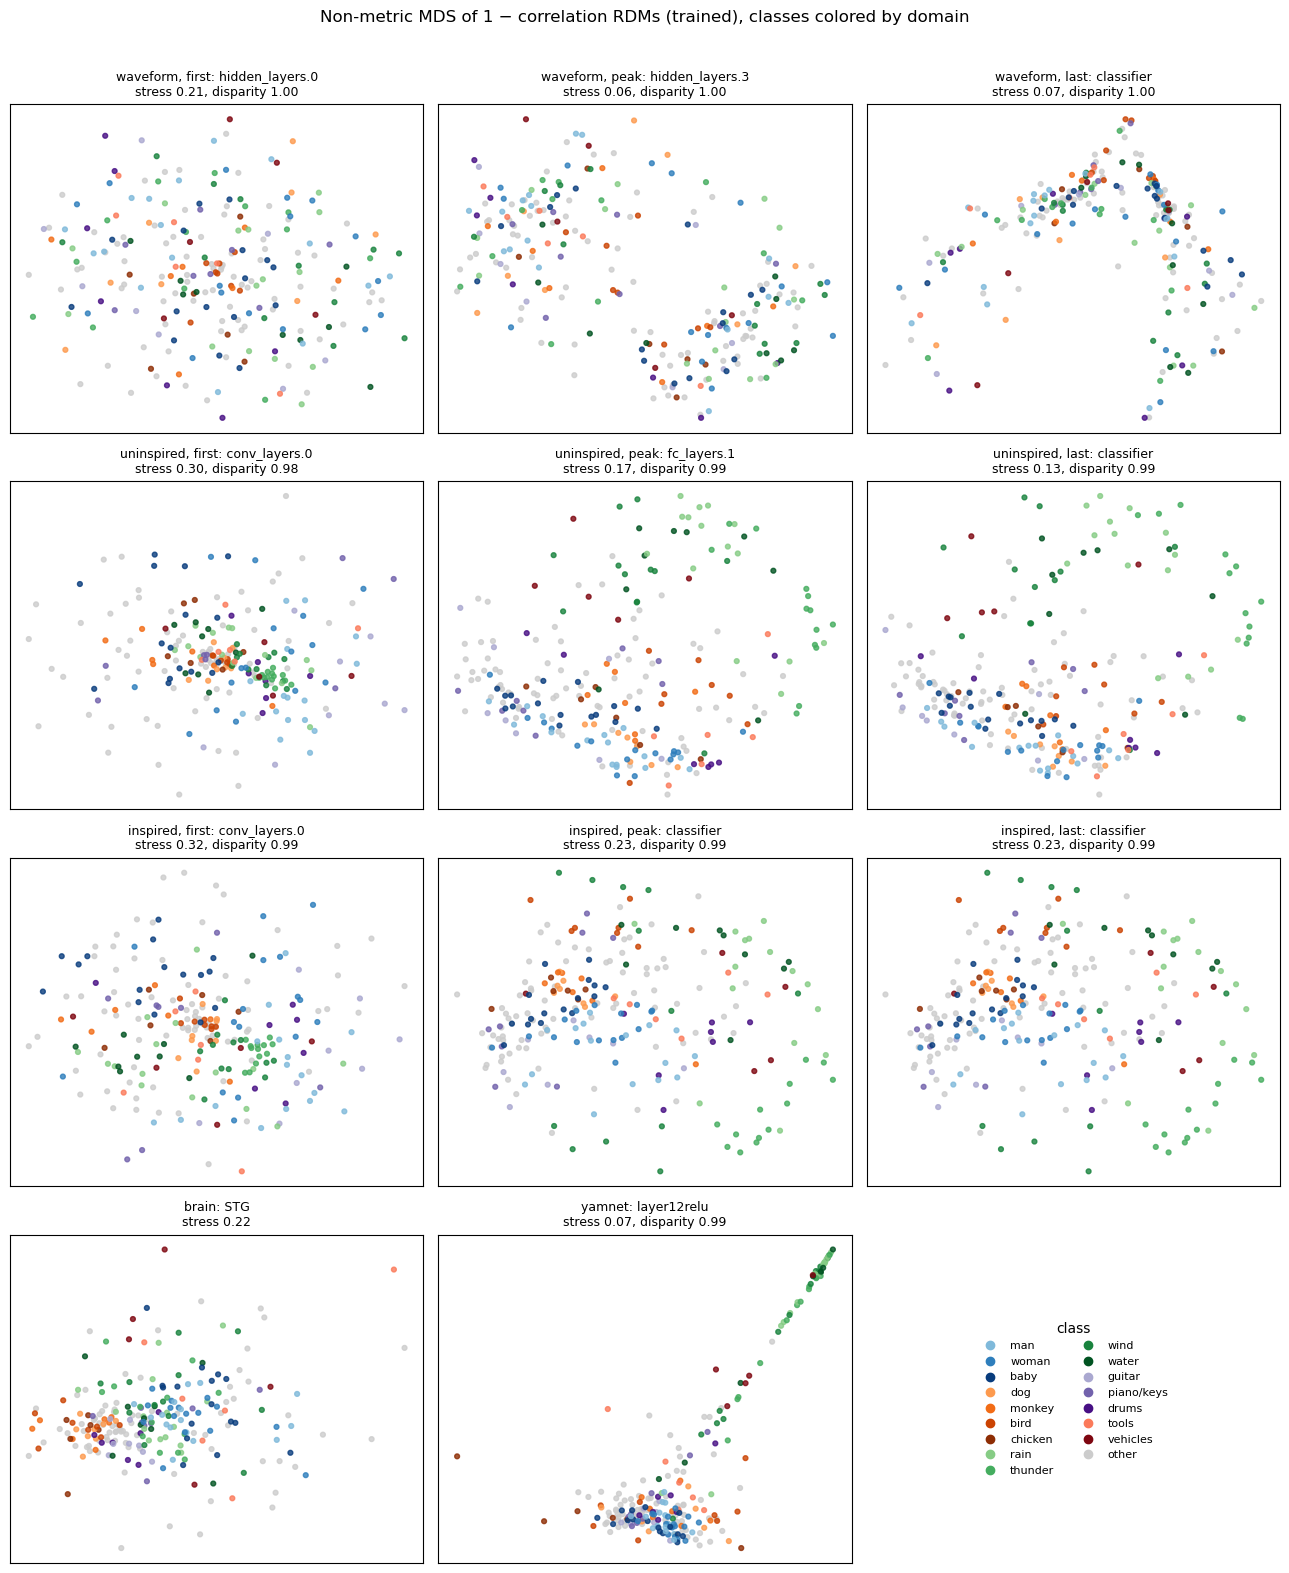

In [83]:
subset_embeddings = {
    key: (name, coords[keep_idx], stress, disparity)
    for key, (name, coords, stress, disparity) in embeddings.items()
}
# highlight = ["man", "woman", "baby", "rain", "dog", "guitar"]
highlight = [
    "man", "rain",
    "woman", "thunder",
    "baby", "guitar",
    "dog", "wind",
    "bird", "drums",
    "monkey", "water",
    "piano/keys", "tools",
    "vehicles",
]
plot_mds_grid(subset_embeddings, subset_labels,
              "Non-metric MDS of 1 − correlation RDMs (trained), classes colored by domain",
              class_colors=class_colors)

The figure above shows non-metric MDS maps of the 1 − correlation RDMs for the first, peak and last layer of one representative trained run per model, together with STG and YAMNet's peak layer. 

Fifteen classes are colored, grouped into five broad domains by color family: voices (blues), animals (oranges), natural forces (greens), music (purples) and mechanical sounds (reds). 

All other classes are shown in gray, and the two largest classes (man, woman) were downsampled to 16 sounds each for visibility. 

In the first layers of all models, sounds form a diffuse cloud with at most a weak grouping of rain and thunder, and the high stress (0.21–0.32) indicates that this geometry is poorly captured in two dimensions. With depth, a clear domain structure emerges in the uninspired and inspired models: natural forces separate from the other sounds, while human voices and animal vocalizations stay in a shared region. The inspired model partly separates animals from human voices within that region. The waveform model develops a low-dimensional arc in its deeper layers (stress 0.06–0.07), but the domains remain mixed along it. STG shows a weaker but visible organization, with animal vocalizations grouping on one side and human voices on the other, whereas natural forces are spread out. YAMNet shows the most pronounced structure: natural forces and vehicles form an elongated arm that is clearly separated from a compact cluster of voices, animals and music. Procrustes disparities close to 1 for all models indicate that none of the 2D maps resembles the STG map in its overall layout, consistent with the low RSA alignment. The models mainly separate natural forces from vocalizations, whereas STG appears to distinguish animal from human vocalizations more clearly.

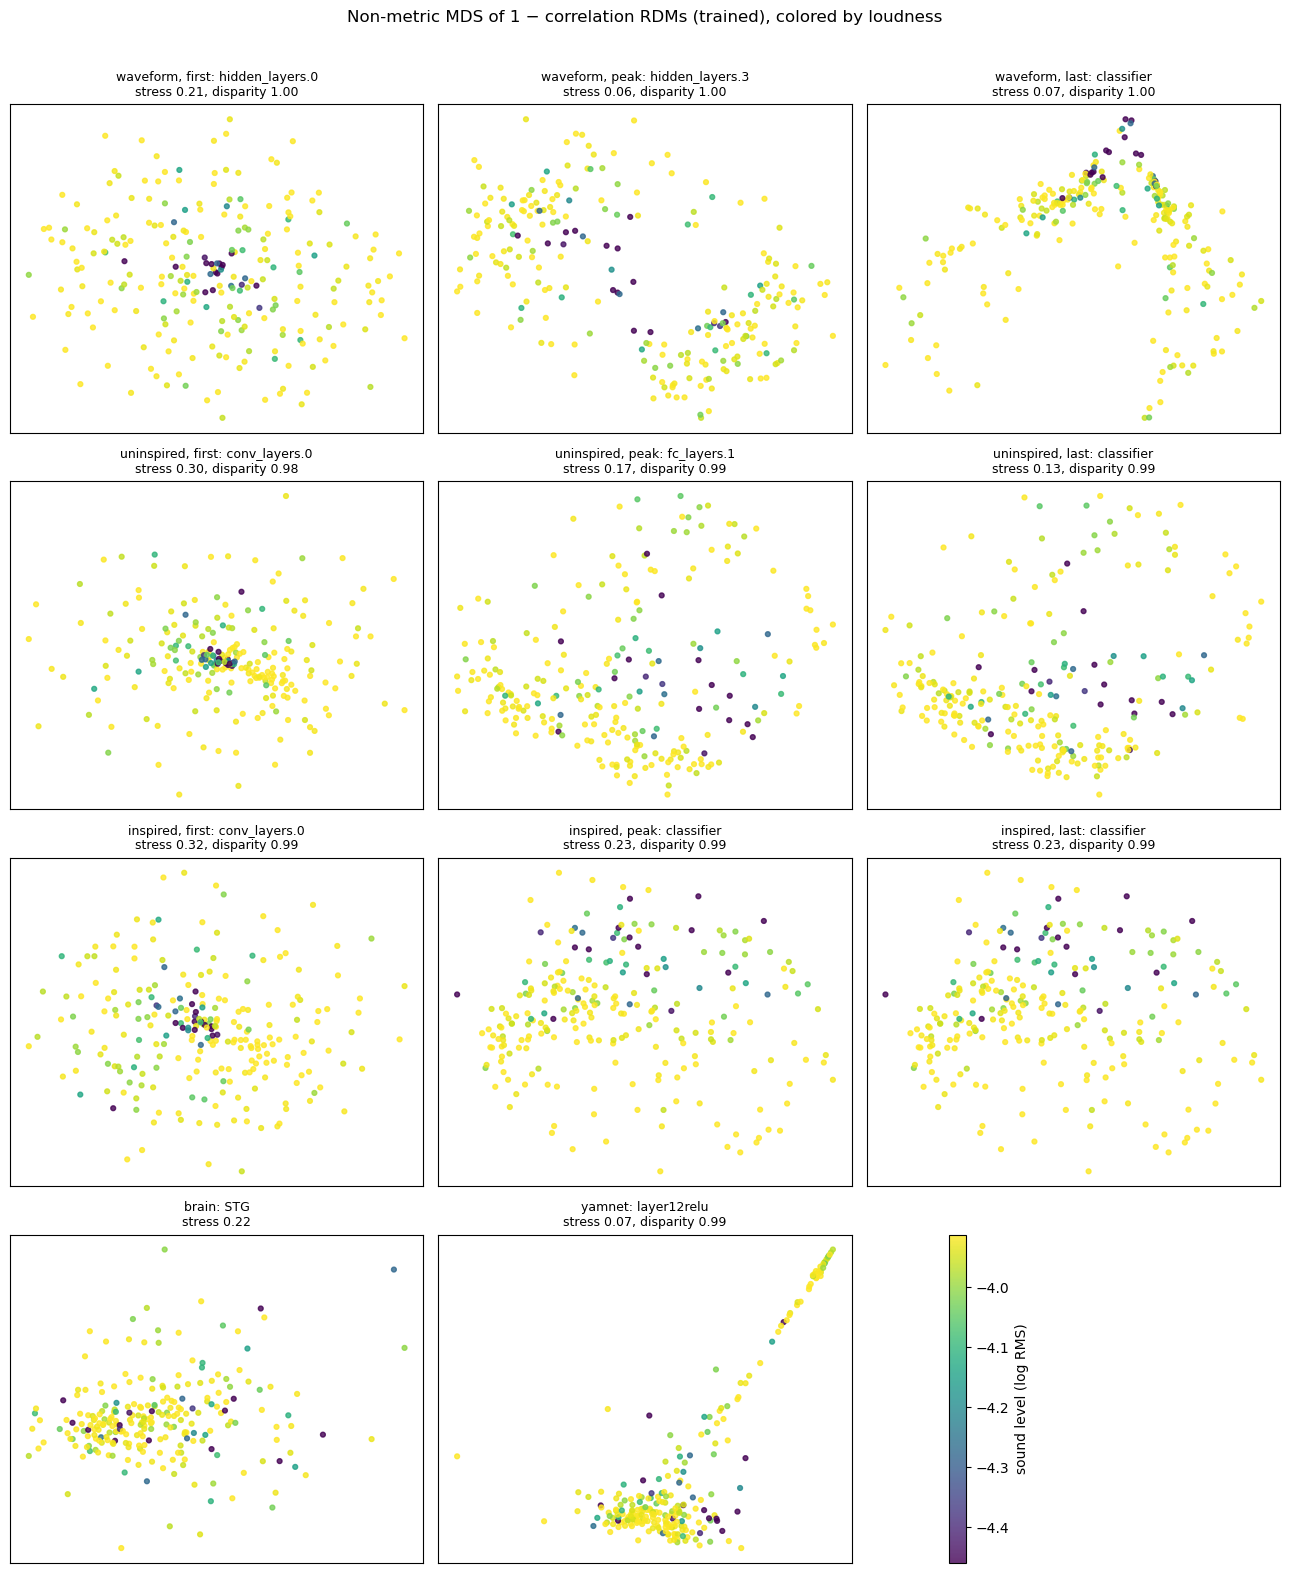

In [84]:
plot_mds_grid(subset_embeddings, log_rms[keep_idx],
              "Non-metric MDS of 1 − correlation RDMs (trained), colored by loudness",
              categorical=False)

Coloring the same MDS maps by sound level (log RMS amplitude) shows how strongly level shapes each representation. 
Because the stimuli are largely level-normalized, the color scale was limited to the 5th–95th percentile, so the variation mainly concerns the lowest-level quarter of the sounds. 

In the first layer of all three models, the lowest-level sounds formed a tight cluster in the center of the map, indicating that weak inputs produce similar, nondistinctive activation patterns. 

In the deeper layers of the waveform model, these sounds moved to one extreme of its low-dimensional arc, making sound level one of the dominant axes of its geometry. 
In the uninspired and inspired models, low-level sounds also moved away from the main cloud of normal-level sounds, but were spread out rather than clustered. 
In contrast, STG showed no systematic organization by level, with a few low-level sounds at the periphery of the map. YAMNet's main axis separated natural sounds from the other classes rather than by level. 

These maps are consistent with the correlations between the model RDMs and the sound-level RDM: the strongly negative correlations of the waveform layers reflect low-level sounds being represented as similar to all others, whereas the weakly positive correlation of STG reflects a few low-level sounds that are dissimilar to the rest.

MDS shows the dominant structure of each representation, but this is an unsupervised methof. 
So a representation can contain category information that is simply not its main axis of variation, for example when loudness dominates the geometry. 
To test whether category information is linearly available, we therefore added cross-validated Linear Discriminant Analysis (LDA). Each sound's pattern was z-scored across features, matching the 1 − correlation used in the RSA, and reduced to 30 principal components. LDA with shrinkage was then fitted to the category labels (28 classes after merging categories with fewer than six sounds). Because LDA is supervised and the number of features far exceeds the number of sounds, it can separate even random labels on the training data. We therefore report only held-out results: the projection of sounds not used for fitting (50/50 split), and the 5-fold cross-validated balanced accuracy, whose chance level is 1/28 regardless of class imbalance. MDS and LDA thus answer complementary questions: how the representation is organized, and whether categories can be read out from it.

In [85]:
def row_zscore(x: np.ndarray) -> np.ndarray:
    """Z-scores each sound's pattern across its features.

    Euclidean geometry on z-scored patterns matches the 1 - correlation used in the RSA.

    Args:
        x: Patterns of shape (n_sounds, n_features).

    Returns:
        The z-scored patterns.
    """
    std = x.std(axis=1, keepdims=True)
    return (x - x.mean(axis=1, keepdims=True)) / np.where(std == 0, 1, std)


def to_matrix(acts) -> np.ndarray:
    """Flattens activations or brain responses to shape (n_sounds, n_features).

    Args:
        acts: Numpy array or torch tensor with the sounds along the first axis.

    Returns:
        A float32 matrix.
    """
    if isinstance(acts, torch.Tensor):
        acts = acts.numpy()
    acts = np.asarray(acts, dtype=np.float32)
    return acts.reshape(acts.shape[0], -1)


def cv_lda(acts, labels: np.ndarray, n_pca: int = 30, seed: int = 0) -> tuple[np.ndarray, np.ndarray, float]:
    """Cross-validated LDA projection and decoding accuracy.

    Args:
        acts: Patterns with the sounds along the first axis.
        labels: One class label per sound.
        n_pca: Number of PCA components before LDA.
        seed: Random seed for the splits.

    Returns:
        The LDA coordinates of the held-out half, their labels, and the 5-fold
        cross-validated balanced accuracy.
    """
    x = to_matrix(acts)
    n_classes = len(np.unique(labels))

    def make_model():
        return make_pipeline(
            FunctionTransformer(row_zscore),
            PCA(n_components=min(n_pca, x.shape[1]), random_state=seed),
            LinearDiscriminantAnalysis(solver="eigen", shrinkage="auto", n_components=min(2, n_classes - 1)),
        )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    # with 28 classes, each test fold has more classes than half its size, which triggers a harmless warning
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="The number of unique classes is greater than 50%")
        accuracy = cross_val_score(make_model(), x, labels, cv=cv, scoring="balanced_accuracy").mean()

        x_train, x_test, y_train, y_test = train_test_split(x, labels, test_size=0.5, stratify=labels,
                                                            random_state=seed)
        coords = make_model().fit(x_train, y_train).transform(x_test)

    return coords, y_test, accuracy


def plot_lda_grid(lda_results: dict, class_labels: np.ndarray, title: str,
                  class_colors: dict[str, tuple] | None = None) -> None:
    """Plots held-out LDA projections of the selected layers, the brain and YAMNet.

    Args:
        lda_results: Maps a panel key to (layer name, coordinates, labels, accuracy).
        class_labels: All class labels, used for the chance level.
        title: Figure title.
        class_colors: Maps the classes to color to their colors; all other classes are drawn in grey.
            None gives every class its own color.
    """
    positions = ["first", "peak", "last"]
    grey = (0.8, 0.8, 0.8, 1.0)
    if class_colors is None:
        palette = plt.get_cmap("tab20")
        class_colors = {c: palette(i % 20) for i, c in enumerate(dict.fromkeys(class_labels))}
    chance = 1 / len(np.unique(class_labels))
    rng = np.random.default_rng(0)

    n_rows = len(models) + 1
    fig, axes = plt.subplots(n_rows, 3, figsize=(13, 4 * n_rows))
    grid = {(r, c): (m, p) for r, m in enumerate(models) for c, p in enumerate(positions)}
    grid[(len(models), 0)] = "brain"
    grid[(len(models), 1)] = "yamnet"

    for (row, col), key in grid.items():
        ax = axes[row, col]
        name, coords, labels, accuracy = lda_results[key]
        # with two classes LDA gives one axis, so spread the points vertically for visibility
        y = coords[:, 1] if coords.shape[1] > 1 else rng.uniform(-1, 1, len(coords))
        point_colors = np.array([class_colors.get(c, grey) for c in labels])
        # grey points first, so the colored classes are drawn on top
        order = np.argsort([c in class_colors for c in labels], kind="stable")
        ax.scatter(coords[order, 0], y[order], c=point_colors[order], s=14, alpha=0.8)
        label = key if isinstance(key, str) else f"{key[0]}, {key[1]}"
        ax.set_title(f"{label}: {name}\nbalanced accuracy {accuracy:.2f} (chance {chance:.2f})", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

    legend_ax = axes[len(models), 2]
    legend_ax.axis("off")
    handles = [plt.Line2D([], [], marker="o", linestyle="", color=color, label=c)
               for c, color in class_colors.items()]
    if any(c not in class_colors for c in class_labels):
        handles.append(plt.Line2D([], [], marker="o", linestyle="", color=grey, label="other"))
    legend_ax.legend(handles=handles, loc="center", title="class", frameon=False, ncol=2, fontsize=8)

    fig.suptitle(title)
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()  

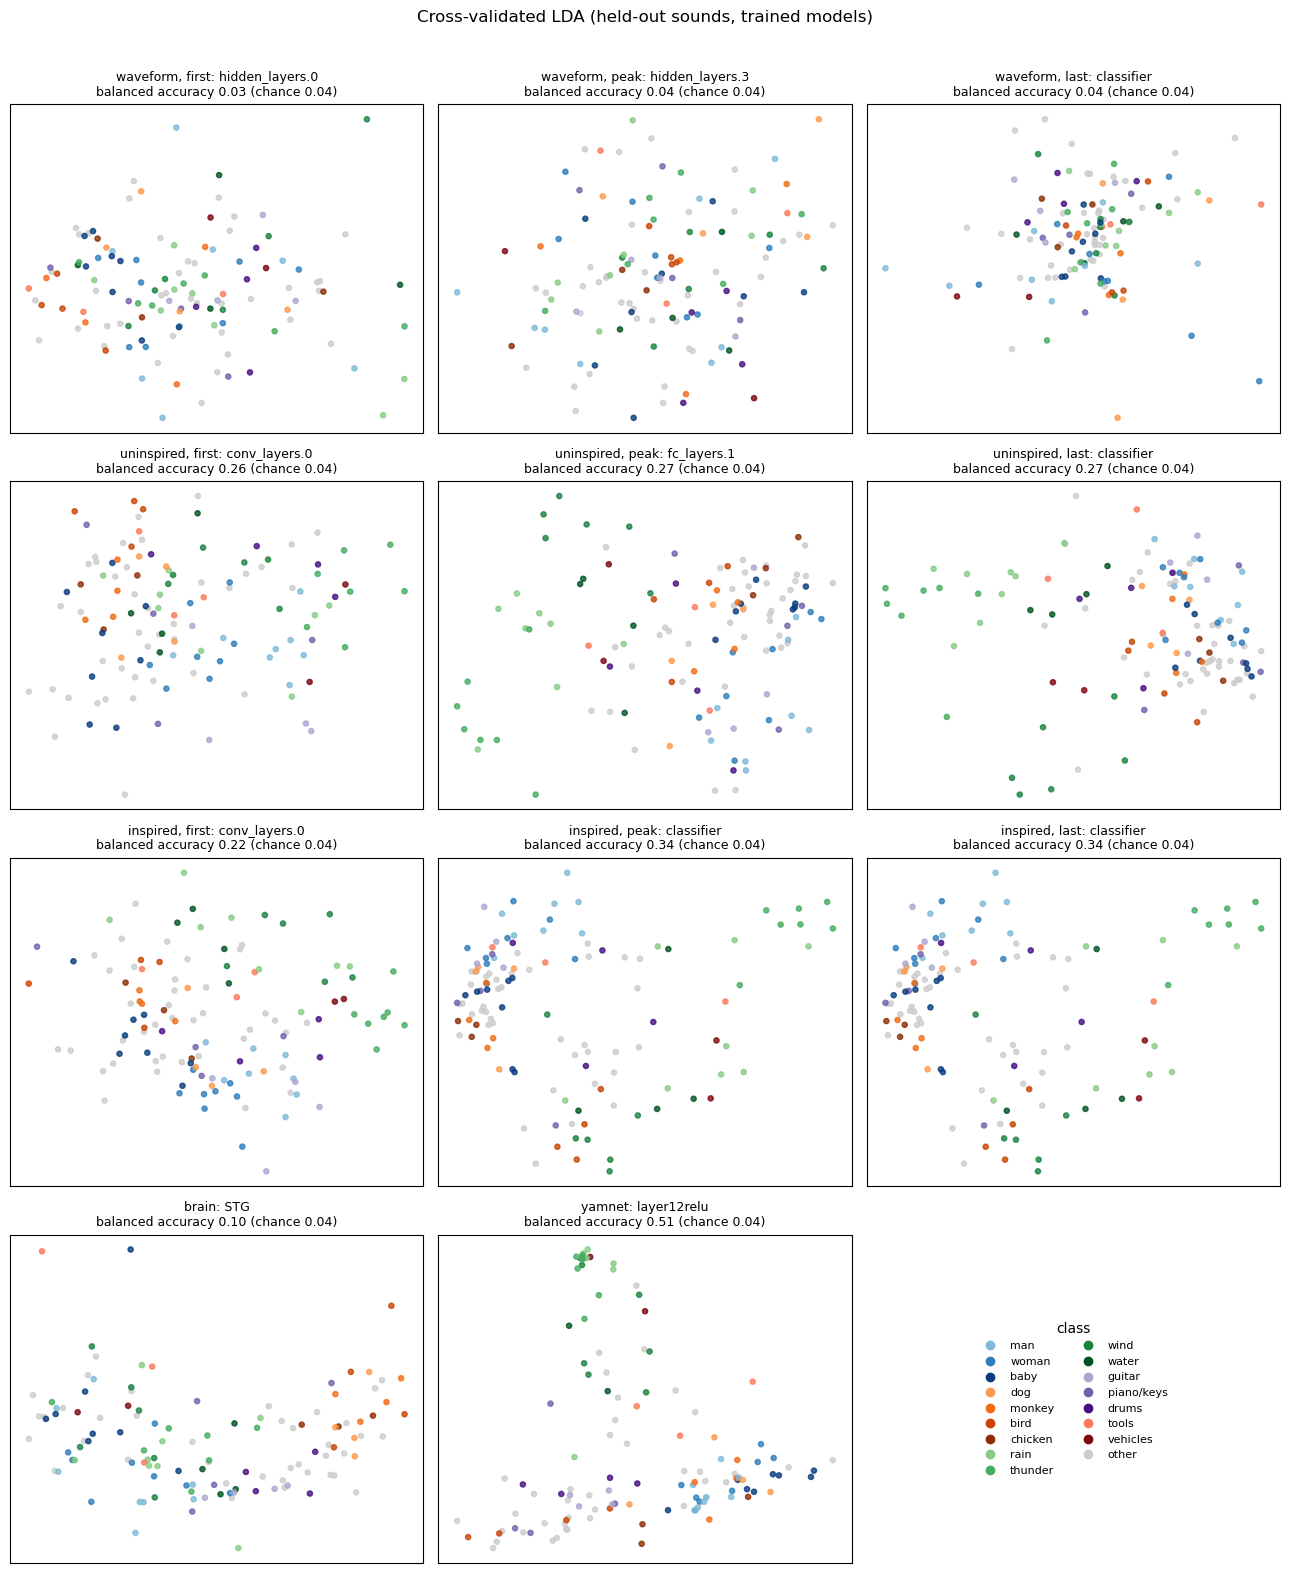

In [86]:
class_labels = subset_labels

lda_panels = {}
for model_name in models:
    layer_names = list(trained_layer_scores[model_name])
    mean_scores = [trained_layer_scores[model_name][layer].mean() for layer in layer_names]
    peak_layer = layer_names[int(np.argmax(mean_scores))]
    peak_runs = trained_layer_scores[model_name][peak_layer]
    run_idx = int(np.argsort(peak_runs)[len(peak_runs) // 2])
    for position, layer in {"first": layer_names[0], "peak": peak_layer, "last": layer_names[-1]}.items():
        lda_panels[(model_name, position)] = (layer, all_trained_activations[model_name][run_idx][layer])

lda_panels["brain"] = ("STG", brain_data)
lda_panels["yamnet"] = (yamnet_peak, yamnet_activations[yamnet_peak])

lda_results = {
    key: (name, *cv_lda(to_matrix(acts)[keep_idx], class_labels))
    for key, (name, acts) in lda_panels.items()
}

highlight = ["man", "woman", "baby", "rain", "dog", "guitar"]
plot_lda_grid(lda_results, class_labels, "Cross-validated LDA (held-out sounds, trained models)",
              class_colors=class_colors)

Cross-validated LDA showed clear differences in how much category information is linearly available. The waveform model remained at chance in all layers (balanced accuracy 0.03–0.04, chance 0.04). 
The uninspired model reached 0.26 already in its first layer and hardly improved with depth (0.27), indicating that much of the category information is present in its spectrogram input. 
The inspired model started slightly lower (0.22) but gained with depth (0.34). Category information in STG was above chance (0.10) but far below the models, likely reflecting in part the noise in single-participant fMRI patterns. 
YAMNet, trained on a much larger dataset, reached 0.51. In the held-out projections of the deeper layers of the uninspired and inspired models, natural sounds (rain, thunder, wind, water) separated from the other classes, while human voices and animal vocalizations shared a region, partly separated only in the inspired model.
YAMNet showed the same division most clearly. 
STG was organized differently: despite its low accuracy, its projection placed animal vocalizations on one side and human voices on the other, consistent with its MDS map. The models thus mainly distinguish natural sounds from vocalizations, whereas STG mainly distinguishes animal from human vocalizations. Notably, the first uninspired layer showed substantial decoding accuracy despite showing no category structure in MDS, indicating that category information can be present without dominating a representation's geometry. The ranking of the trained models by category decoding (waveform < uninspired < inspired < YAMNet) matches their ranking by peak brain alignment, suggesting that representations that make categories more accessible also tend to resemble STG more closely, although with four models this remains a qualitative observation.